# 3D Orbital Trajectory Animator

## Two-Body Problem & Keplerian Orbits

The motion of a satellite around a central body (e.g., Earth) is governed by the **two-body problem**. Under the assumptions of point masses and no external forces, the satellite follows a **conic section**, an ellipse for bound orbits.

### Classical Orbital Elements

An orbit is uniquely defined by six parameters:

| Element | Symbol | Description |
|---------|--------|-------------|
| Semi-major axis | $a$ | Size of the orbit (km or AU) |
| Eccentricity | $e$ | Shape ($0$ = circular, $0<e<1$ = elliptical) |
| Inclination | $i$ | Tilt relative to reference plane (deg) |
| RAAN | $\Omega$ | Longitude of the ascending node (deg) |
| Arg. of periapsis | $\omega$ | Orientation of the ellipse in its plane (deg) |
| True anomaly | $\nu$ | Position of the satellite along the orbit (deg) |

### Vis-Viva Equation

The velocity at any point in the orbit is given by:

$$
v^2 = \mu \left( \frac{2}{r} - \frac{1}{a} \right)
$$

where $\mu = GM$ is the gravitational parameter, $r$ is the current radius, and $a$ is the semi-major axis.

---

*This notebook uses PyAstronomy's `KeplerEllipse` to solve Kepler's equation and generate 3D position vectors, then animates the trajectory with Matplotlib.*

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from PyAstronomy import pyasl

plt.rcParams.update(
    {
        "figure.facecolor": "#1a1b26",
        "axes.facecolor": "#1a1b26",
        "axes.edgecolor": "#3b4261",
        "axes.labelcolor": "#f8f8f2",
        "text.color": "#f8f8f2",
        "xtick.color": "#565f89",
        "ytick.color": "#565f89",
        "legend.facecolor": "#24253a",
        "legend.edgecolor": "#3b4261",
    }
)


In [65]:
def draw_earth(ax, radius=1.0, color="#ff79c6", linewidth=0.6, alpha=0.6):
    n_theta = 20
    n_phi = 20
    theta = np.linspace(0, 2 * np.pi, n_theta)
    phi = np.linspace(-np.pi / 2, np.pi / 2, n_phi)

    for i in range(0, n_phi, 3):
        x = radius * np.cos(phi[i]) * np.cos(theta)
        y = radius * np.cos(phi[i]) * np.sin(theta)
        z = radius * np.sin(phi[i]) * np.ones_like(theta)
        ax.plot(x, y, z, color=color, linewidth=linewidth, alpha=alpha)

    for i in range(0, n_theta, 3):
        x = radius * np.cos(phi) * np.cos(theta[i])
        y = radius * np.cos(phi) * np.sin(theta[i])
        z = radius * np.sin(phi)
        ax.plot(x, y, z, color=color, linewidth=linewidth, alpha=alpha)

In [66]:
def compute_orbit(
    a=1.0, per=1.0, e=0.0, Omega=0.0, i=0.0, w=0.0, n_orbits=2, n_points=300
):
    ke = pyasl.KeplerEllipse(a=a, per=per, e=e, Omega=Omega, i=i, w=w)
    t = np.linspace(0, n_orbits * per, n_points)
    pos = ke.xyzPos(t)
    return pos, t, ke

In [67]:
def animate_orbit(fig, ax, pos, frame_skip=2, trail_length=40, interval=30):
    n_frames = len(pos)

    (sat_dot,) = ax.plot(
        [], [], [], "wo", markersize=8, markeredgecolor="white", markeredgewidth=0.5
    )
    (trail_line,) = ax.plot([], [], [], color="#00e5ff", linewidth=1.2, alpha=0.8)
    trail_scat = ax.scatter(
        [], [], [], c=[], cmap="plasma", alpha=0.5, s=8, vmin=0, vmax=1
    )

    n_trail = trail_length

    def setup_axes():
        ax.set_xlim(pos[:, 0].min() * 1.3, pos[:, 0].max() * 1.3)
        ax.set_ylim(pos[:, 1].min() * 1.3, pos[:, 1].max() * 1.3)
        ax.set_zlim(pos[:, 2].min() * 1.3, pos[:, 2].max() * 1.3)
        ax.set_box_aspect([1, 1, 1])
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        ax.xaxis.pane.set_edgecolor("gray")
        ax.yaxis.pane.set_edgecolor("gray")
        ax.zaxis.pane.set_edgecolor("gray")

    setup_axes()

    def init():
        trail_line.set_data([], [])
        trail_line.set_3d_properties([])
        sat_dot.set_data([], [])
        sat_dot.set_3d_properties([])
        return trail_line, sat_dot

    def update(frame):
        i = frame * frame_skip
        if i >= n_frames:
            i = n_frames - 1

        sat_dot.set_data([pos[i, 0]], [pos[i, 1]])
        sat_dot.set_3d_properties([pos[i, 2]])

        start = max(0, i - n_trail)
        trail_pts = pos[start : i + 1]
        trail_line.set_data(trail_pts[:, 0], trail_pts[:, 1])
        trail_line.set_3d_properties(trail_pts[:, 2])

        trail_scat.set_offsets(trail_pts[:, :2])
        trail_scat.set_3d_properties(trail_pts[:, 2], "z")
        ages = np.linspace(0, 1, len(trail_pts))
        trail_scat.set_array(ages)

        return trail_line, sat_dot, trail_scat

    n_anim_frames = n_frames // frame_skip
    anim = animation.FuncAnimation(
        fig,
        update,
        frames=n_anim_frames,
        init_func=init,
        interval=interval,
        blit=False,
        repeat=True,
    )
    return anim

## Low Earth Orbit (LEO) — Single Orbit Demonstration

A **Low Earth Orbit** is approximately circular with low eccentricity ($e \approx 0.01$–$0.05$) and altitudes of 200–2000 km. Here we use dimensionless units ($a = 1.0$ corresponds to ~1 Earth radius).

### Visual Annotations

- **Inclination** $i = 30^\circ$: the orbit is tilted relative to the equator
- **RAAN** $\Omega = 0^\circ$: ascending node aligned with the reference direction
- **Argument of periapsis** $\omega = 0^\circ$: periapsis lies on the line of nodes
- **True anomaly** $\nu$: the satellite's current angular position (animated)

The wireframe grid represents Earth with latitude/longitude lines.

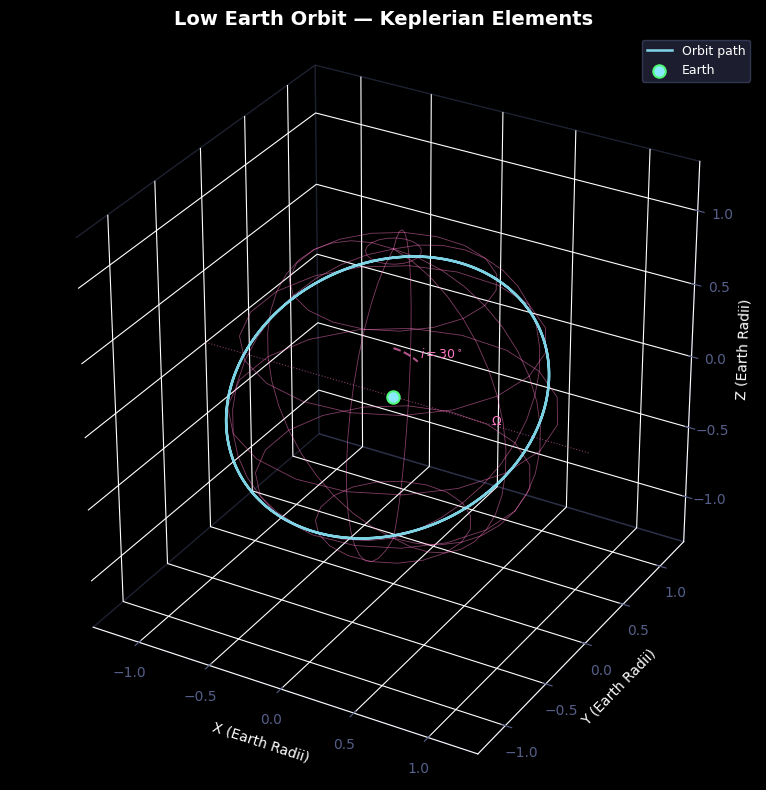

In [68]:
def setup_3d_axes(ax, pos):
    limit = pos[:, :3].max() * 1.4
    ax.set_xlim([-limit, limit])
    ax.set_ylim([-limit, limit])
    ax.set_zlim([-limit, limit])
    ax.set_box_aspect([1, 1, 1])
    ax.set_xlabel("X (Earth Radii)")
    ax.set_ylabel("Y (Earth Radii)")
    ax.set_zlabel("Z (Earth Radii)")
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor("#3b4261")
    ax.yaxis.pane.set_edgecolor("#3b4261")
    ax.zaxis.pane.set_edgecolor("#3b4261")
    ax.tick_params(colors="#565f89")


def annotate_orbital_elements(ax, pos, ke):
    limit = pos[:, :3].max() * 1.4

    # Inclination arc
    if hasattr(ke, "i"):
        i_deg = ke.i
        i_rad = np.radians(i_deg)
        arc_theta = np.linspace(0, i_rad, 30)
        arc_r = pos.max() * 0.35
        arc_x = arc_r * np.sin(arc_theta)
        arc_z = arc_r * np.cos(arc_theta)
        ax.plot(
            arc_x,
            np.zeros_like(arc_x),
            arc_z,
            "--",
            color="#ff79c6",
            linewidth=1.5,
            alpha=0.7,
        )
        ax.text(
            arc_x[-1] * 1.1,
            0,
            arc_z[-1] * 1.1,
            f"$i = {i_deg:.0f}^\\circ$",
            color="#ff79c6",
            fontsize=9,
        )

    # Line of nodes
    nn = 50
    node_line = np.linspace(-limit, limit, nn)
    ax.plot(
        node_line,
        np.zeros(nn),
        np.zeros(nn),
        color="#ff79c6",
        linewidth=0.8,
        linestyle=":",
        alpha=0.5,
    )
    ax.text(limit * 0.5, 0, 0, r"$\Omega$", color="#ff79c6", fontsize=9)

    # Earth at origin
    ax.scatter(
        0,
        0,
        0,
        c="#8be9fd",
        s=80,
        marker="o",
        edgecolors="#50fa7b",
        linewidth=1.5,
        zorder=10,
        label="Earth",
    )


pos_leo, t_leo, ke_leo = compute_orbit(
    a=1.0, per=1.0, e=0.05, i=30.0, Omega=0.0, w=0.0, n_orbits=2, n_points=400
)

plt.style.use("dark_background")
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
setup_3d_axes(ax, pos_leo)
draw_earth(ax, radius=1.0, color="#ff79c6", alpha=0.5)

ax.plot(
    pos_leo[:, 0],
    pos_leo[:, 1],
    pos_leo[:, 2],
    color="#8be9fd",
    linewidth=1.8,
    alpha=0.9,
    label="Orbit path",
)

annotate_orbital_elements(ax, pos_leo, ke_leo)
ax.legend(loc="upper right", fontsize=9, facecolor="#24253a", edgecolor="#3b4261")
ax.set_title(
    "Low Earth Orbit — Keplerian Elements",
    color="white",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

In [69]:
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d


class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return min(zs)


def animate_leo_with_velocity():
    pos, t, ke = compute_orbit(
        a=1.0, per=1.0, e=0.05, i=30.0, Omega=0.0, w=0.0, n_orbits=2, n_points=400
    )

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")
    setup_3d_axes(ax, pos)
    draw_earth(ax, radius=1.0, color="#ff79c6", alpha=0.5)
    ax.plot(
        pos[:, 0],
        pos[:, 1],
        pos[:, 2],
        color="#3b4261",
        linewidth=0.8,
        alpha=0.4,
        label="Full orbit",
    )
    ax.legend(loc="upper right", fontsize=9, facecolor="#24253a", edgecolor="#3b4261")
    ax.set_title("LEO — Animated", color="white", fontsize=14, fontweight="bold")

    (sat,) = ax.plot(
        [], [], [], "wo", markersize=8, markeredgecolor="white", markeredgewidth=1
    )
    (trail,) = ax.plot([], [], [], color="#8be9fd", linewidth=2, alpha=0.9)
    vel_arrow = Arrow3D(
        [0, 0],
        [0, 0],
        [0, 0],
        mutation_scale=15,
        lw=2,
        arrowstyle="-|>",
        color="#ff5555",
        visible=False,
    )
    ax.add_artist(vel_arrow)

    trail_len = 50
    dt = t[1] - t[0]

    def init():
        sat.set_data([], [])
        sat.set_3d_properties([])
        trail.set_data([], [])
        trail.set_3d_properties([])
        vel_arrow.set_visible(False)
        return sat, trail, vel_arrow

    def update(frame):
        sat.set_data([pos[frame, 0]], [pos[frame, 1]])
        sat.set_3d_properties([pos[frame, 2]])

        start = max(0, frame - trail_len)
        trail.set_data(pos[start : frame + 1, 0], pos[start : frame + 1, 1])
        trail.set_3d_properties(pos[start : frame + 1, 2])

        if frame > 1:
            v = (pos[frame] - pos[frame - 1]) / dt
            v_norm = v / (np.linalg.norm(v) + 1e-12)
            arrow_scale = 0.3
            tip = pos[frame] + v_norm * arrow_scale
            vel_arrow.set_positions(pos[frame], tip)
            vel_arrow.set_visible(True)
        else:
            vel_arrow.set_visible(False)

        return sat, trail, vel_arrow

    anim = animation.FuncAnimation(
        fig,
        update,
        frames=len(pos),
        init_func=init,
        interval=30,
        blit=False,
        repeat=True,
    )
    return anim


ani = animate_leo_with_velocity()
from matplotlib.animation import PillowWriter

ani.save("outputs/leo_animated.gif", writer=PillowWriter(fps=30))
plt.close()


![LEO with velocity vector and comet trail](outputs/leo_animated.gif)


## Comparing Orbit Regimes

Different mission requirements demand different orbits. Here we overlay four canonical orbit types:

| Orbit | $a$ | $e$ | $i$ | Purpose |
|-------|-----|-----|-----|---------|
| **LEO** (Low Earth Orbit) | 1.1 | 0.02 | $30^\circ$ | Earth observation, ISS |
| **GEO** (Geostationary) | 1.0 | 0.00 | $0^\circ$ | Communications, weather |
| **Polar** | 1.1 | 0.01 | $90^\circ$ | Reconnaissance, mapping |
| **Molniya** | 1.0 | 0.74 | $63.4^\circ$ | High-latitude communications |

The **Molniya orbit** is a highly elliptical orbit with $e \approx 0.74$ and critical inclination $i = 63.4^\circ$, which prevents apsidal precession and keeps apogee fixed over the northern hemisphere, ideal for Russia/Canada.

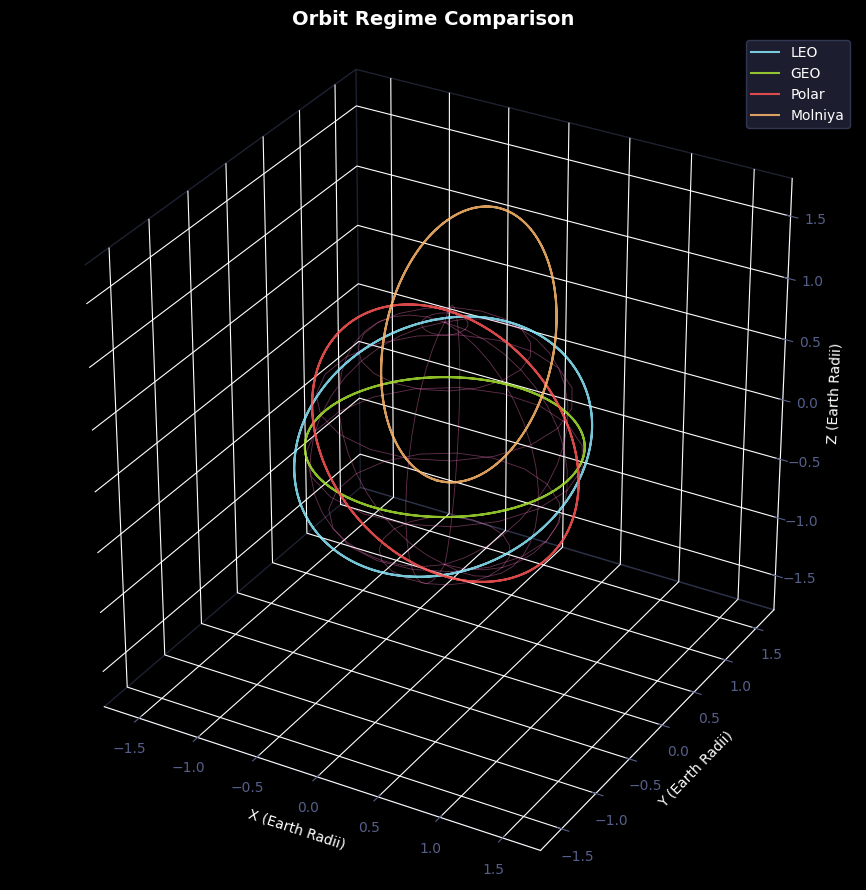

In [70]:
orbits_config = [
    dict(label="LEO", a=1.1, e=0.02, i=30.0, Omega=0, w=0, color="#8be9fd"),
    dict(label="GEO", a=1.0, e=0.00, i=0.0, Omega=0, w=0, color="#a6e22e"),
    dict(label="Polar", a=1.1, e=0.01, i=90.0, Omega=0, w=0, color="#ff5555"),
    dict(label="Molniya", a=1.0, e=0.74, i=63.4, Omega=0, w=270, color="#ffb86c"),
]

plt.style.use("dark_background")
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

limit = 1.8
ax.set_xlim([-limit, limit])
ax.set_ylim([-limit, limit])
ax.set_zlim([-limit, limit])
ax.set_box_aspect([1, 1, 1])
ax.set_xlabel("X (Earth Radii)")
ax.set_ylabel("Y (Earth Radii)")
ax.set_zlabel("Z (Earth Radii)")
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("#3b4261")
ax.yaxis.pane.set_edgecolor("#3b4261")
ax.zaxis.pane.set_edgecolor("#3b4261")
ax.tick_params(colors="#565f89")
ax.set_title("Orbit Regime Comparison", color="white", fontsize=14, fontweight="bold")

draw_earth(ax, radius=1.0, color="#ff79c6", alpha=0.4)

orbit_data = {}
for cfg in orbits_config:
    pos, _, _ = compute_orbit(
        a=cfg["a"],
        e=cfg["e"],
        i=cfg["i"],
        Omega=cfg["Omega"],
        w=cfg["w"],
        n_orbits=2,
        n_points=400,
    )
    orbit_data[cfg["label"]] = pos
    ax.plot(
        pos[:, 0],
        pos[:, 1],
        pos[:, 2],
        color=cfg["color"],
        linewidth=1.5,
        alpha=0.85,
        label=cfg["label"],
    )

ax.legend(loc="upper right", fontsize=10, facecolor="#24253a", edgecolor="#3b4261")
plt.tight_layout()
plt.show()

In [71]:
def animate_multi_orbit(orbit_data, n_frames=200, interval=40):
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection="3d")

    limit = 1.8
    ax.set_xlim([-limit, limit])
    ax.set_ylim([-limit, limit])
    ax.set_zlim([-limit, limit])
    ax.set_box_aspect([1, 1, 1])
    ax.set_xlabel("X (Earth Radii)")
    ax.set_ylabel("Y (Earth Radii)")
    ax.set_zlabel("Z (Earth Radii)")
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor("#3b4261")
    ax.yaxis.pane.set_edgecolor("#3b4261")
    ax.zaxis.pane.set_edgecolor("#3b4261")
    ax.tick_params(colors="#565f89")
    ax.set_title(
        "Multi-Orbit Animation — All Regimes",
        color="white",
        fontsize=14,
        fontweight="bold",
    )

    draw_earth(ax, radius=1.0, color="#ff79c6", alpha=0.4)

    colors = ["#8be9fd", "#a6e22e", "#ff5555", "#ffb86c"]
    dots = {}
    trails = {}

    for idx, (label, pos) in enumerate(orbit_data.items()):
        n_pts = len(pos)
        step = max(1, n_pts // n_frames)
        pos_sampled = pos[::step][:n_frames]

        (dot,) = ax.plot(
            [],
            [],
            [],
            "o",
            color=colors[idx],
            markersize=7,
            markeredgecolor="white",
            markeredgewidth=0.5,
            label=label,
        )
        (trail,) = ax.plot([], [], [], color=colors[idx], linewidth=1.2, alpha=0.6)
        dots[label] = dict(dot=dot, pos=pos_sampled)
        trails[label] = trail

    ax.legend(loc="upper right", fontsize=9, facecolor="#24253a", edgecolor="#3b4261")

    def update(frame):
        artists = []
        for label, d in dots.items():
            i = min(frame, len(d["pos"]) - 1)
            d["dot"].set_data([d["pos"][i, 0]], [d["pos"][i, 1]])
            d["dot"].set_3d_properties([d["pos"][i, 2]])

            trail_len = 30
            start = max(0, i - trail_len)
            trails[label].set_data(
                d["pos"][start : i + 1, 0], d["pos"][start : i + 1, 1]
            )
            trails[label].set_3d_properties(d["pos"][start : i + 1, 2])
            artists.extend([d["dot"], trails[label]])
        return artists

    anim = animation.FuncAnimation(
        fig, update, frames=n_frames, interval=interval, blit=False, repeat=True
    )
    return anim


ani_multi = animate_multi_orbit(orbit_data, n_frames=200, interval=40)
ani_multi.save("outputs/multi_orbit.gif", writer=PillowWriter(fps=25))
plt.close()


![Multi-orbit comparison — LEO, GEO, Polar, Molniya](outputs/multi_orbit.gif)


## Molniya Orbit — High-Latitude Communications

The **Molniya** (Russian: "lightning") orbit is a highly elliptical orbit with:

- **High eccentricity** $e \approx 0.74$
- **Critical inclination** $i = 63.4^\circ$ (or $116.6^\circ$)
- **Argument of perigee** $\omega = 270^\circ$ (apogee at northernmost point)

### Why $63.4^\circ$?

At this **critical inclination**, apsidal precession is zero, the line of apsides stays fixed. This means the apogee (where the satellite spends most of its time) remains over the northern hemisphere, providing long-duration coverage for high-latitude regions (Russia, Canada, Scandinavia).

### Orbital Period & Apogee Dwell

Period = $1$ orbital period. The satellite slows down near apogee (Kepler's second law), "dwelling" for several hours over the target region before sweeping quickly through perigee.

In [72]:
def animate_molniya():
    pos, t, ke = compute_orbit(
        a=1.0, per=1.0, e=0.74, i=63.4, Omega=0.0, w=270.0, n_orbits=1, n_points=400
    )

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    limit = 1.9
    ax.set_xlim([-limit, limit])
    ax.set_ylim([-limit, limit])
    ax.set_zlim([-limit, limit])
    ax.set_box_aspect([1, 1, 1])
    ax.set_xlabel("X (Earth Radii)")
    ax.set_ylabel("Y (Earth Radii)")
    ax.set_zlabel("Z (Earth Radii)")
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor("#3b4261")
    ax.yaxis.pane.set_edgecolor("#3b4261")
    ax.zaxis.pane.set_edgecolor("#3b4261")
    ax.tick_params(colors="#565f89")
    ax.set_title(
        "Molniya Orbit — $e=0.74,\\; i=63.4^\\circ$",
        color="white",
        fontsize=14,
        fontweight="bold",
    )
    ax.text2D(
        0.02,
        0.02,
        "Apogee dwell over northern hemisphere",
        transform=ax.transAxes,
        color="#ffb86c",
        fontsize=10,
        style="italic",
    )

    draw_earth(ax, radius=1.0, color="#ff79c6", alpha=0.5)

    (dark_line,) = ax.plot(
        pos[:, 0], pos[:, 1], pos[:, 2], color="#3b4261", linewidth=0.6, alpha=0.4
    )

    (sat,) = ax.plot(
        [],
        [],
        [],
        "o",
        color="#ffb86c",
        markersize=9,
        markeredgecolor="white",
        markeredgewidth=0.5,
    )

    (trail,) = ax.plot([], [], [], color="#ffb86c", linewidth=2, alpha=0.85)

    trail_len = 60

    def init():
        sat.set_data([], [])
        sat.set_3d_properties([])
        trail.set_data([], [])
        trail.set_3d_properties([])
        return sat, trail

    def update(frame):
        sat.set_data([pos[frame, 0]], [pos[frame, 1]])
        sat.set_3d_properties([pos[frame, 2]])

        start = max(0, frame - trail_len)
        trail.set_data(pos[start : frame + 1, 0], pos[start : frame + 1, 1])
        trail.set_3d_properties(pos[start : frame + 1, 2])
        return sat, trail

    anim = animation.FuncAnimation(
        fig,
        update,
        frames=len(pos),
        init_func=init,
        interval=30,
        blit=False,
        repeat=True,
    )
    return anim


ani_molniya = animate_molniya()
ani_molniya.save("outputs/molniya.gif", writer=PillowWriter(fps=30))
plt.close()


![Molniya orbit — e=0.74, i=63.4°, apogee dwell](outputs/molniya.gif)


## Interactive Orbital Parameter Explorer

Use the sliders below to explore how each Keplerian element affects the orbit.
The plot updates in real time.

| Slider | Range | Effect |
|--------|-------|--------|
| **$a$** | 0.8 – 2.0 | Orbit size |
| **$e$** | 0.0 – 0.9 | Orbit shape (circular → elliptical) |
| **$i$** | 0 – 180° | Tilt relative to equatorial plane |
| **$\Omega$** | 0 – 360° | Rotation of the ascending node |
| **$\omega$** | 0 – 360° | Rotation of the ellipse within its plane |

Try setting $e = 0.74$, $i = 63.4^\circ$, $\omega = 270^\circ$ to see the Molniya orbit emerge.

In [73]:
import ipywidgets as widgets
from IPython.display import display


def interactive_orbit(a, e, i, Omega, w):
    pos, _, _ = compute_orbit(a=a, e=e, i=i, Omega=Omega, w=w, n_orbits=2, n_points=300)

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")

    limit = max(pos.max() * 1.4, 1.5)
    ax.set_xlim([-limit, limit])
    ax.set_ylim([-limit, limit])
    ax.set_zlim([-limit, limit])
    ax.set_box_aspect([1, 1, 1])
    ax.set_xlabel("X (Earth Radii)")
    ax.set_ylabel("Y (Earth Radii)")
    ax.set_zlabel("Z (Earth Radii)")
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor("#3b4261")
    ax.yaxis.pane.set_edgecolor("#3b4261")
    ax.zaxis.pane.set_edgecolor("#3b4261")
    ax.tick_params(colors="#565f89")

    draw_earth(ax, radius=1.0, color="#ff79c6", alpha=0.4)

    ax.plot(pos[:, 0], pos[:, 1], pos[:, 2], color="#8be9fd", linewidth=2, alpha=0.9)
    ax.scatter(
        pos[0, 0], pos[0, 1], pos[0, 2], c="white", s=30, marker="o", label="Start"
    )

    ax.set_title(
        f"Orbit: a={a:.2f}, e={e:.2f}, i={i:.0f}°",
        color="white",
        fontsize=13,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()


a_slider = widgets.FloatSlider(
    value=1.0,
    min=0.8,
    max=2.0,
    step=0.05,
    description="a (semi-major)",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="400px"),
)
e_slider = widgets.FloatSlider(
    value=0.3,
    min=0.0,
    max=0.9,
    step=0.01,
    description="e (eccentricity)",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="400px"),
)
i_slider = widgets.FloatSlider(
    value=30,
    min=0,
    max=180,
    step=1,
    description="i (inclination)",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="400px"),
)
Omega_slider = widgets.FloatSlider(
    value=0,
    min=0,
    max=360,
    step=5,
    description="Ω (RAAN)",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="400px"),
)
w_slider = widgets.FloatSlider(
    value=0,
    min=0,
    max=360,
    step=5,
    description="ω (arg. periapsis)",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="400px"),
)

ui = widgets.VBox(
    [
        widgets.HBox([a_slider, e_slider]),
        widgets.HBox([i_slider, Omega_slider]),
        widgets.HBox([w_slider]),
    ]
)

out = widgets.interactive_output(
    interactive_orbit,
    {"a": a_slider, "e": e_slider, "i": i_slider, "Omega": Omega_slider, "w": w_slider},
)
display(ui, out)

Output()

## Summary

This notebook demonstrates:

- Solving the two-body problem using `PyAstronomy.KeplerEllipse`
- 3D visualization of Keplerian orbits with orbital element annotations
- Animated satellite motion with comet trails and velocity vectors
- Comparison of four orbit regimes: LEO, GEO, Polar, and Molniya
- Interactive parameter exploration via Jupyter widgets

### Key Engineering Takeaways

| Concept | Application |
|---------|-------------|
| Kepler's laws govern all bound orbital motion | Mission design, orbit determination |
| Inclination determines latitude coverage | Polar = global, equatorial = regional |
| Critical inclination ($63.4^\circ$) eliminates apsidal drift | Molniya, Tundra orbits |
| Highly elliptical orbits provide apogee dwell | Comms at high latitudes |
| Orbital elements are a complete parameterization | Any Keplerian orbit can be described with 6 parameters |

### References

- PyAstronomy documentation: [https://pyastronomy.readthedocs.io/](https://pyastronomy.readthedocs.io/)
- Vallado, D. A. — *Fundamentals of Astrodynamics and Applications*
- Bate, R. R., Mueller, D. D., & White, J. E. — *Fundamentals of Astrodynamics*